# step1. load data and NMF

In [1]:
import pickle
from scipy.cluster.hierarchy import dendrogram, leaves_list, linkage

import matplotlib.pyplot as plt
from matplotlib import font_manager

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (auc, confusion_matrix, f1_score, matthews_corrcoef,
                             precision_score, roc_curve)
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import NMF

In [2]:
seed = None

In [3]:
def load_data(filepath):
    try:
        df_ori = pd.read_csv(filepath, index_col=0)
        return df_ori
    except FileNotFoundError:
        print(f"The file {filepath} was not found.")
        return None
    except pd.errors.ParserError as e:
        print(f"Error parsing the file {filepath}: {e}")
        return None

In [4]:
def select_columns(df, column_names):
    return df[column_names]

In [5]:
def get_column_names(prefixes, suffixes):
    return [f"{prefix}_{suffix}" for prefix in prefixes for suffix in suffixes]

In [6]:
df_names = [
    "MGC_ptosis", "MGC_diplopia", "MGC_eyelid_closure", "MGC_speech", "MGC_chewing", 
    "MGC_swallowing", "MGC_respiration", "MGC_neck", "MGC_upper_limb", "MGC_lower_limb",
    "MGADL_speech", "MGADL_chewing", "MGADL_swallowing", "MGADL_respiration", 
    "MGADL_toothbrushing", "MGADL_getting_up", "MGADL_diplopia", "MGADL_ptosis",
    "MGQOL1_dissatisfaction", "MGQOL2_seeing", "MGQOL3_eating", 
    "MGQOL4_social_activity_restriction", "MGQOL5_hobby_entertainment", "MGQOL6_family_role", 
    "MGQOL7_behavior_modification", "MGQOL8_work_impact", "MGQOL9_speaking", 
    "MGQOL10_driving", "MGQOL11_feeling_down", "MGQOL12_walking", "MGQOL13_quick_action", 
    "MGQOL14_mental_crushing", "MGQOL15_dressing"
]

In [7]:
config = {
    "filepath": "./data/df_4th.csv",
}

df_ori = load_data(config["filepath"])

if df_ori is not None:
    df = select_columns(df_ori, df_names)

In [8]:
numeric_columns = df.select_dtypes(include='number')
scaler = MinMaxScaler()
scaled_columns = scaler.fit_transform(numeric_columns)
df[numeric_columns.columns] = scaled_columns

/var/folders/9v/25ky5ynx3fv57ncrm5lt41980000gn/T/ipykernel_33613/2307295889.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numeric_columns.columns] = scaled_columns


In [9]:
nmf = NMF(n_components=4, init='nndsvda', max_iter=200, random_state=0)

W = nmf.fit_transform(df)
H = nmf.components_

In [10]:
def cluster_data(matrix, method='complete', metric='euclidean'):
    cluster_rows = linkage(matrix, method=method, metric=metric)
    return leaves_list(cluster_rows)

feature_names = df.columns

row_order = cluster_data(H)
col_order = cluster_data(H.T)

In [11]:
H_reordered = H[row_order][:, col_order]
feature_names_reordered = feature_names[col_order]

module_names = ["module QOL", "module Diplopia", "module Ptosis", "module Systemic"]
module_names_reordered = [module_names[i] for i in row_order]

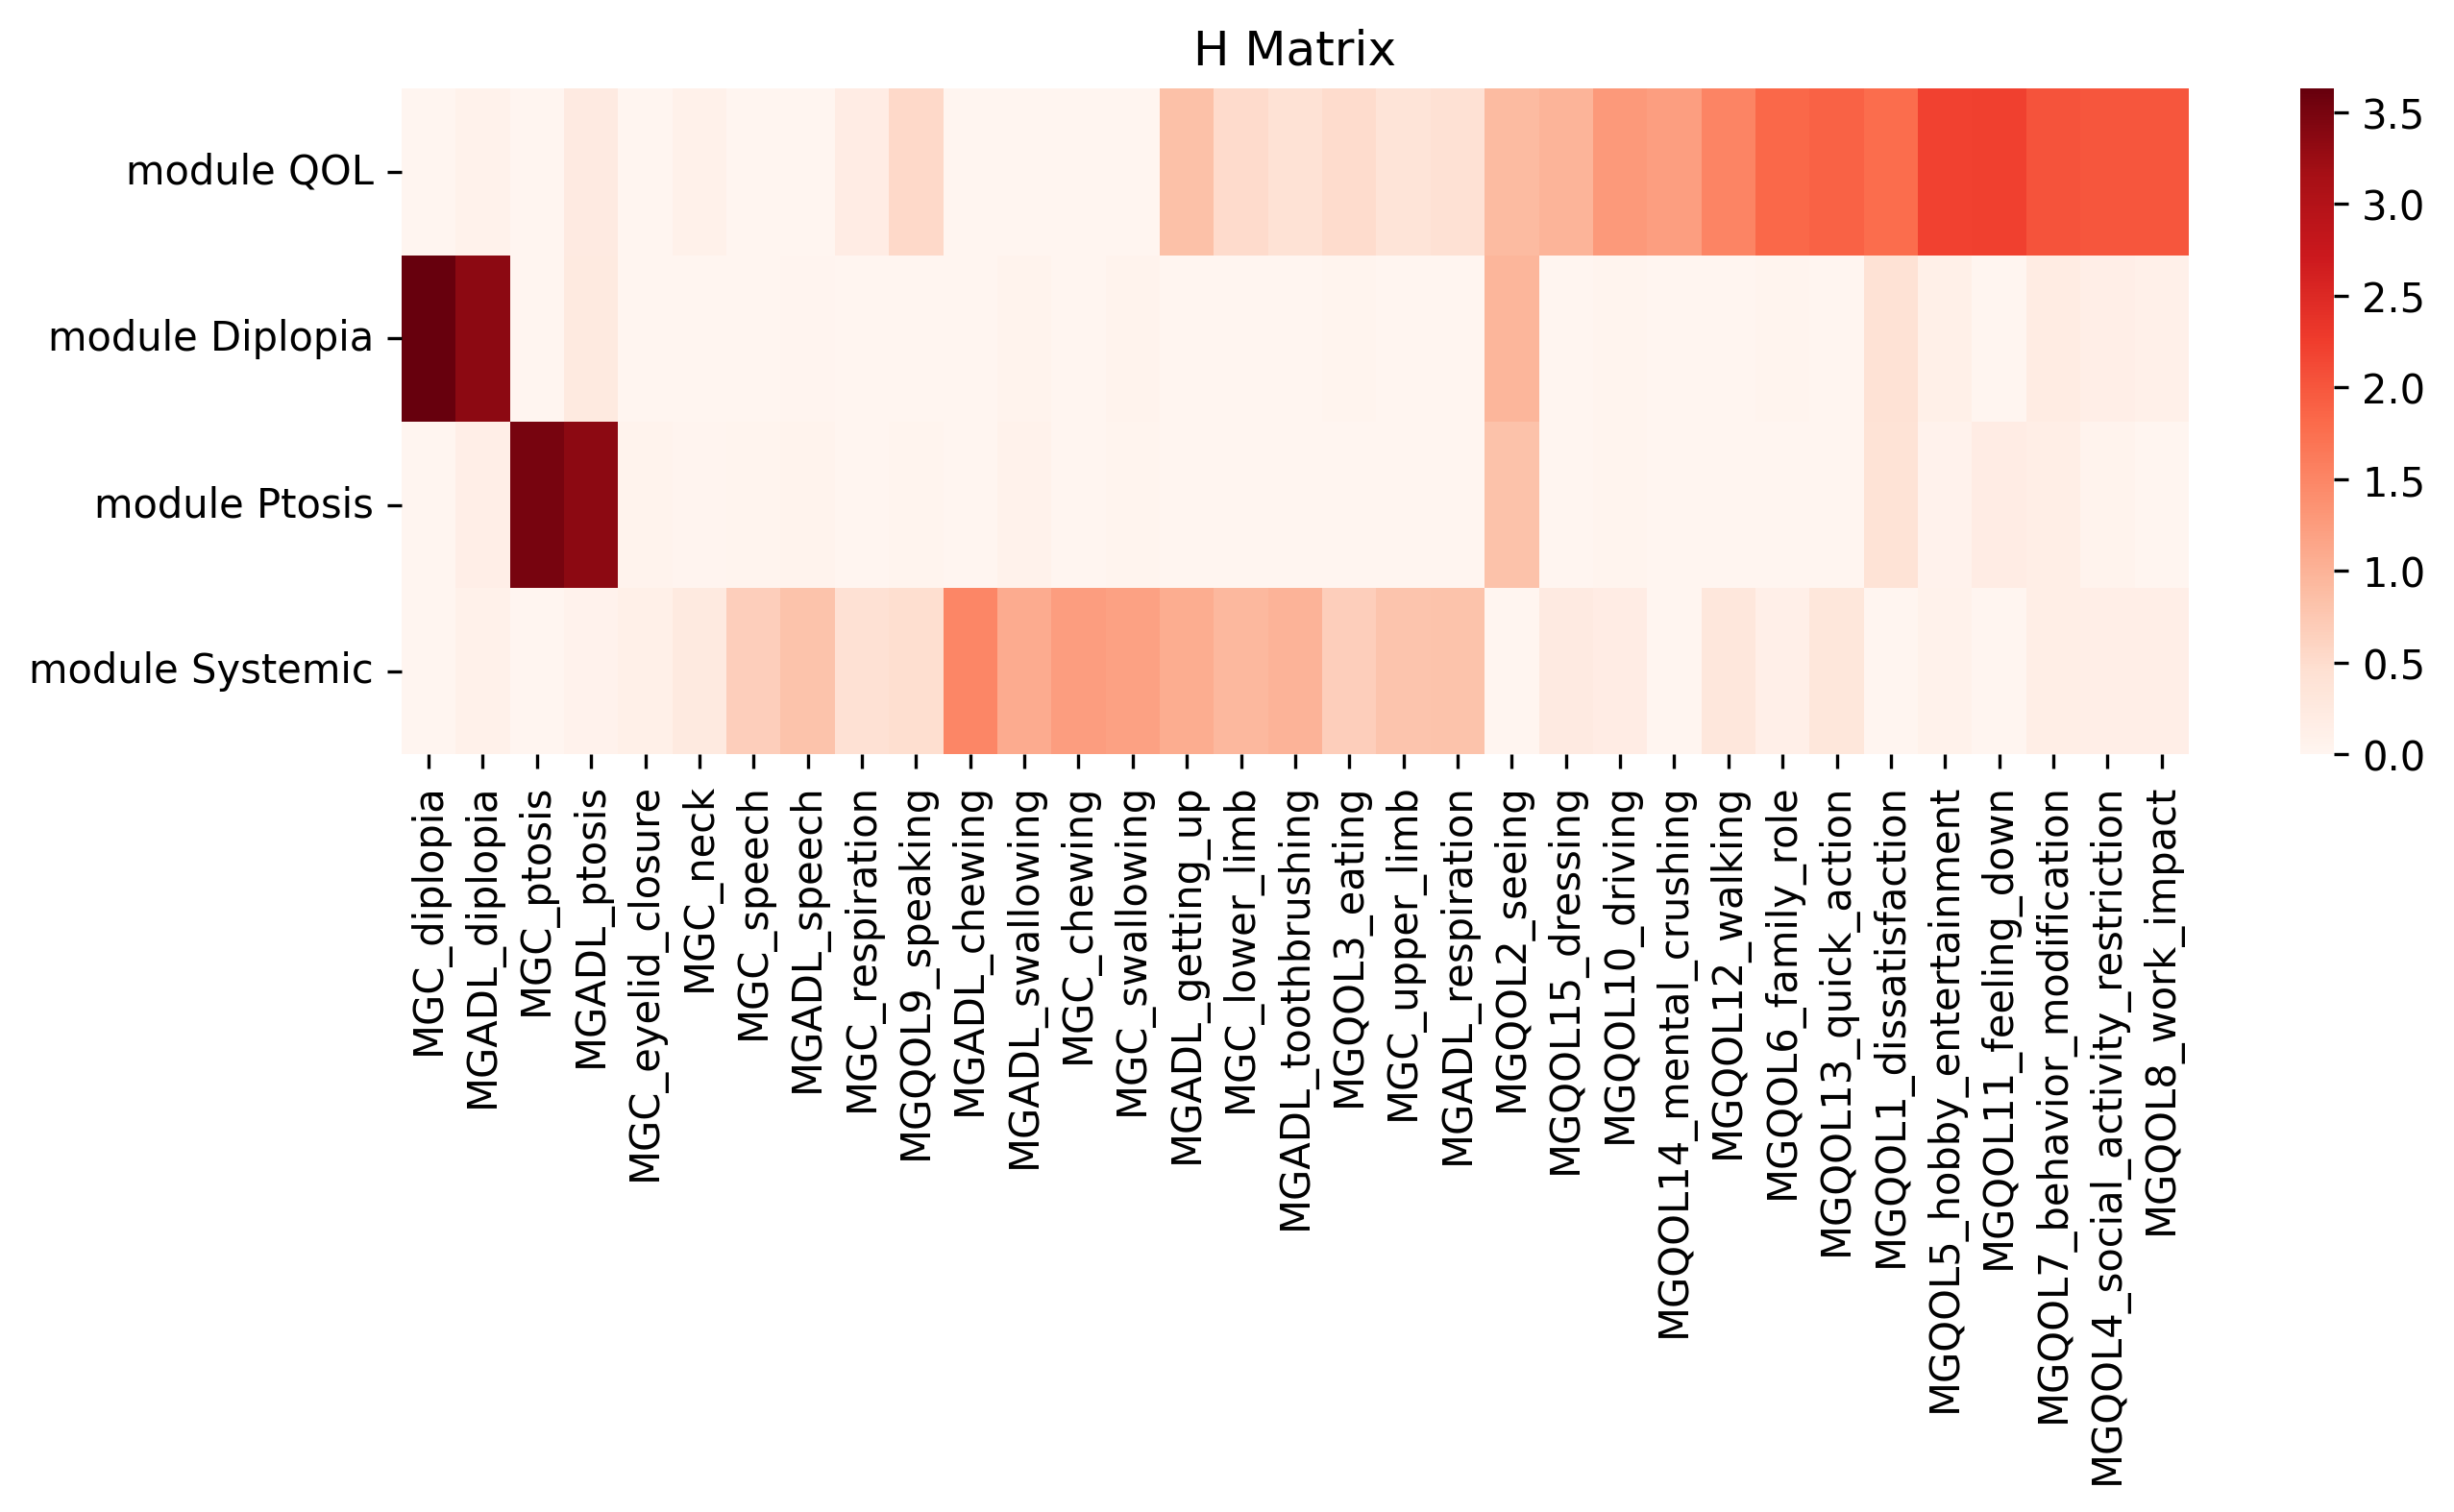

In [12]:
plt.figure(figsize=(10, 3), dpi=300)
sns.heatmap(H_reordered, cmap="Reds", xticklabels=feature_names_reordered, yticklabels=module_names_reordered)
plt.title("H Matrix")

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.show()

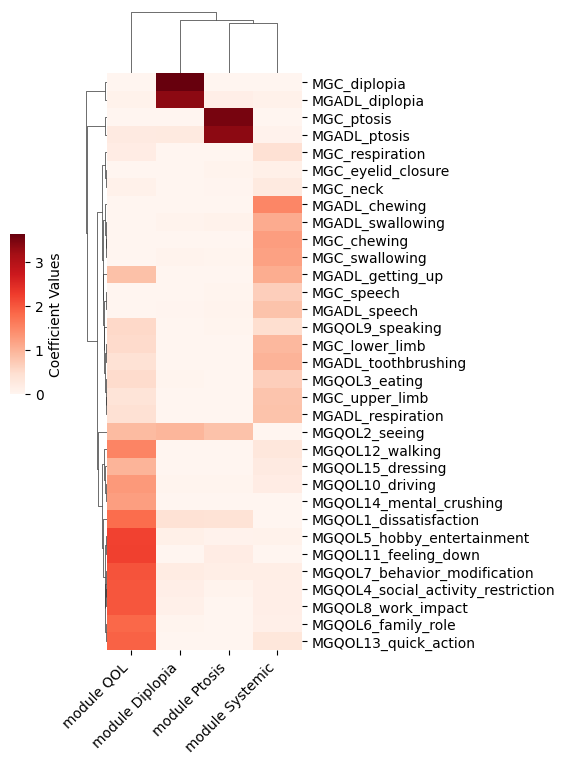

In [13]:
# Convert the H matrix to a DataFrame
H_df = pd.DataFrame(H, columns=df.columns)

# Transpose the DataFrame
H_df = H_df.T

# Rename the columns
H_df.columns = ["module QOL", "module Diplopia", "module Ptosis", "module Systemic"]

# Create a clustermap with dendrogram and heatmap
fig = sns.clustermap(H_df,
               cmap="Reds",
               xticklabels=True,
               yticklabels=True,
               figsize=(5, 8),
               dendrogram_ratio=(0.1, 0.1),
               cbar_pos=(-0.12, 0.5, 0.03, 0.2),
               cbar_kws={'label': 'Coefficient Values'})

# Rotate x-axis labels for better readability and align them to the right
plt.setp(fig.ax_heatmap.get_xticklabels(), rotation=45, ha="right") 

plt.show()

fig.savefig('./fig/fig2.pdf', dpi=1500)
fig.savefig('./fig/fig2.tiff', dpi=1200)

In [14]:
IDs = df_ori['ID']
W_with_id = np.column_stack((IDs, W))
module_names_with_id = ['ID'] + module_names_reordered
W_with_id_df = pd.DataFrame(W_with_id, columns=module_names_with_id)

In [15]:
module_names_with_id = ['ID', "module QOL", "module Diplopia", "module Ptosis", "module Systemic"]

W_with_id_df = pd.DataFrame(W_with_id, columns=module_names_with_id)
MM_data = df_ori[["ID", "MMorbetter"]]

W_MM = pd.merge(W_with_id_df, MM_data, on="ID")
W_MM.index = W_MM['ID']
W_MM.drop(columns=['ID'], inplace=True)

In [16]:
with open('./out/nmf_model.pkl', 'wb') as file:
    pickle.dump(nmf, file)

with open('./out/W_matrix.pkl', 'wb') as file:
    pickle.dump(W, file)

with open('./out/H_matrix.pkl', 'wb') as file:
    pickle.dump(H, file)

with open('./out/W_with_id_df.pkl', 'wb') as file:
    pickle.dump(W_with_id_df, file)

with open('./out/W_MM.pkl', 'wb') as file:
    pickle.dump(W_MM, file)

In [17]:
# MMorbetterの値ごとにデータを分割
grouped_data = W_MM.groupby("MMorbetter")
MM0 = grouped_data.get_group(0)
MM1 = grouped_data.get_group(1)

# Create a new boolean column to classify data points based on optimal cutpoint
W_MM['Group'] = np.where(W_MM['MMorbetter'] == 1, 'MM1', 'MM0')

# Create a DataFrame with the median values of each feature for MM0 and MM1
MM0_median = MM0.median()
MM1_median = MM1.median()
med_df = pd.DataFrame({"MM0_median": MM0_median, "MM1_median": MM1_median}).drop(['MMorbetter'], axis=0)


# Function to calculate IQR
def iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    return IQR

# Create a DataFrame with the median and IQR values of each feature for MM0 and MM1
MM0_iqr = iqr(MM0)
MM1_iqr = iqr(MM1)

iqr_df = pd.DataFrame({"MM0_median": MM0_median, "MM1_median": MM1_median, "MM0_iqr": MM0_iqr, "MM1_iqr": MM1_iqr}).drop(['MMorbetter'])

/var/folders/9v/25ky5ynx3fv57ncrm5lt41980000gn/T/ipykernel_33613/3456214195.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(med_df.index)


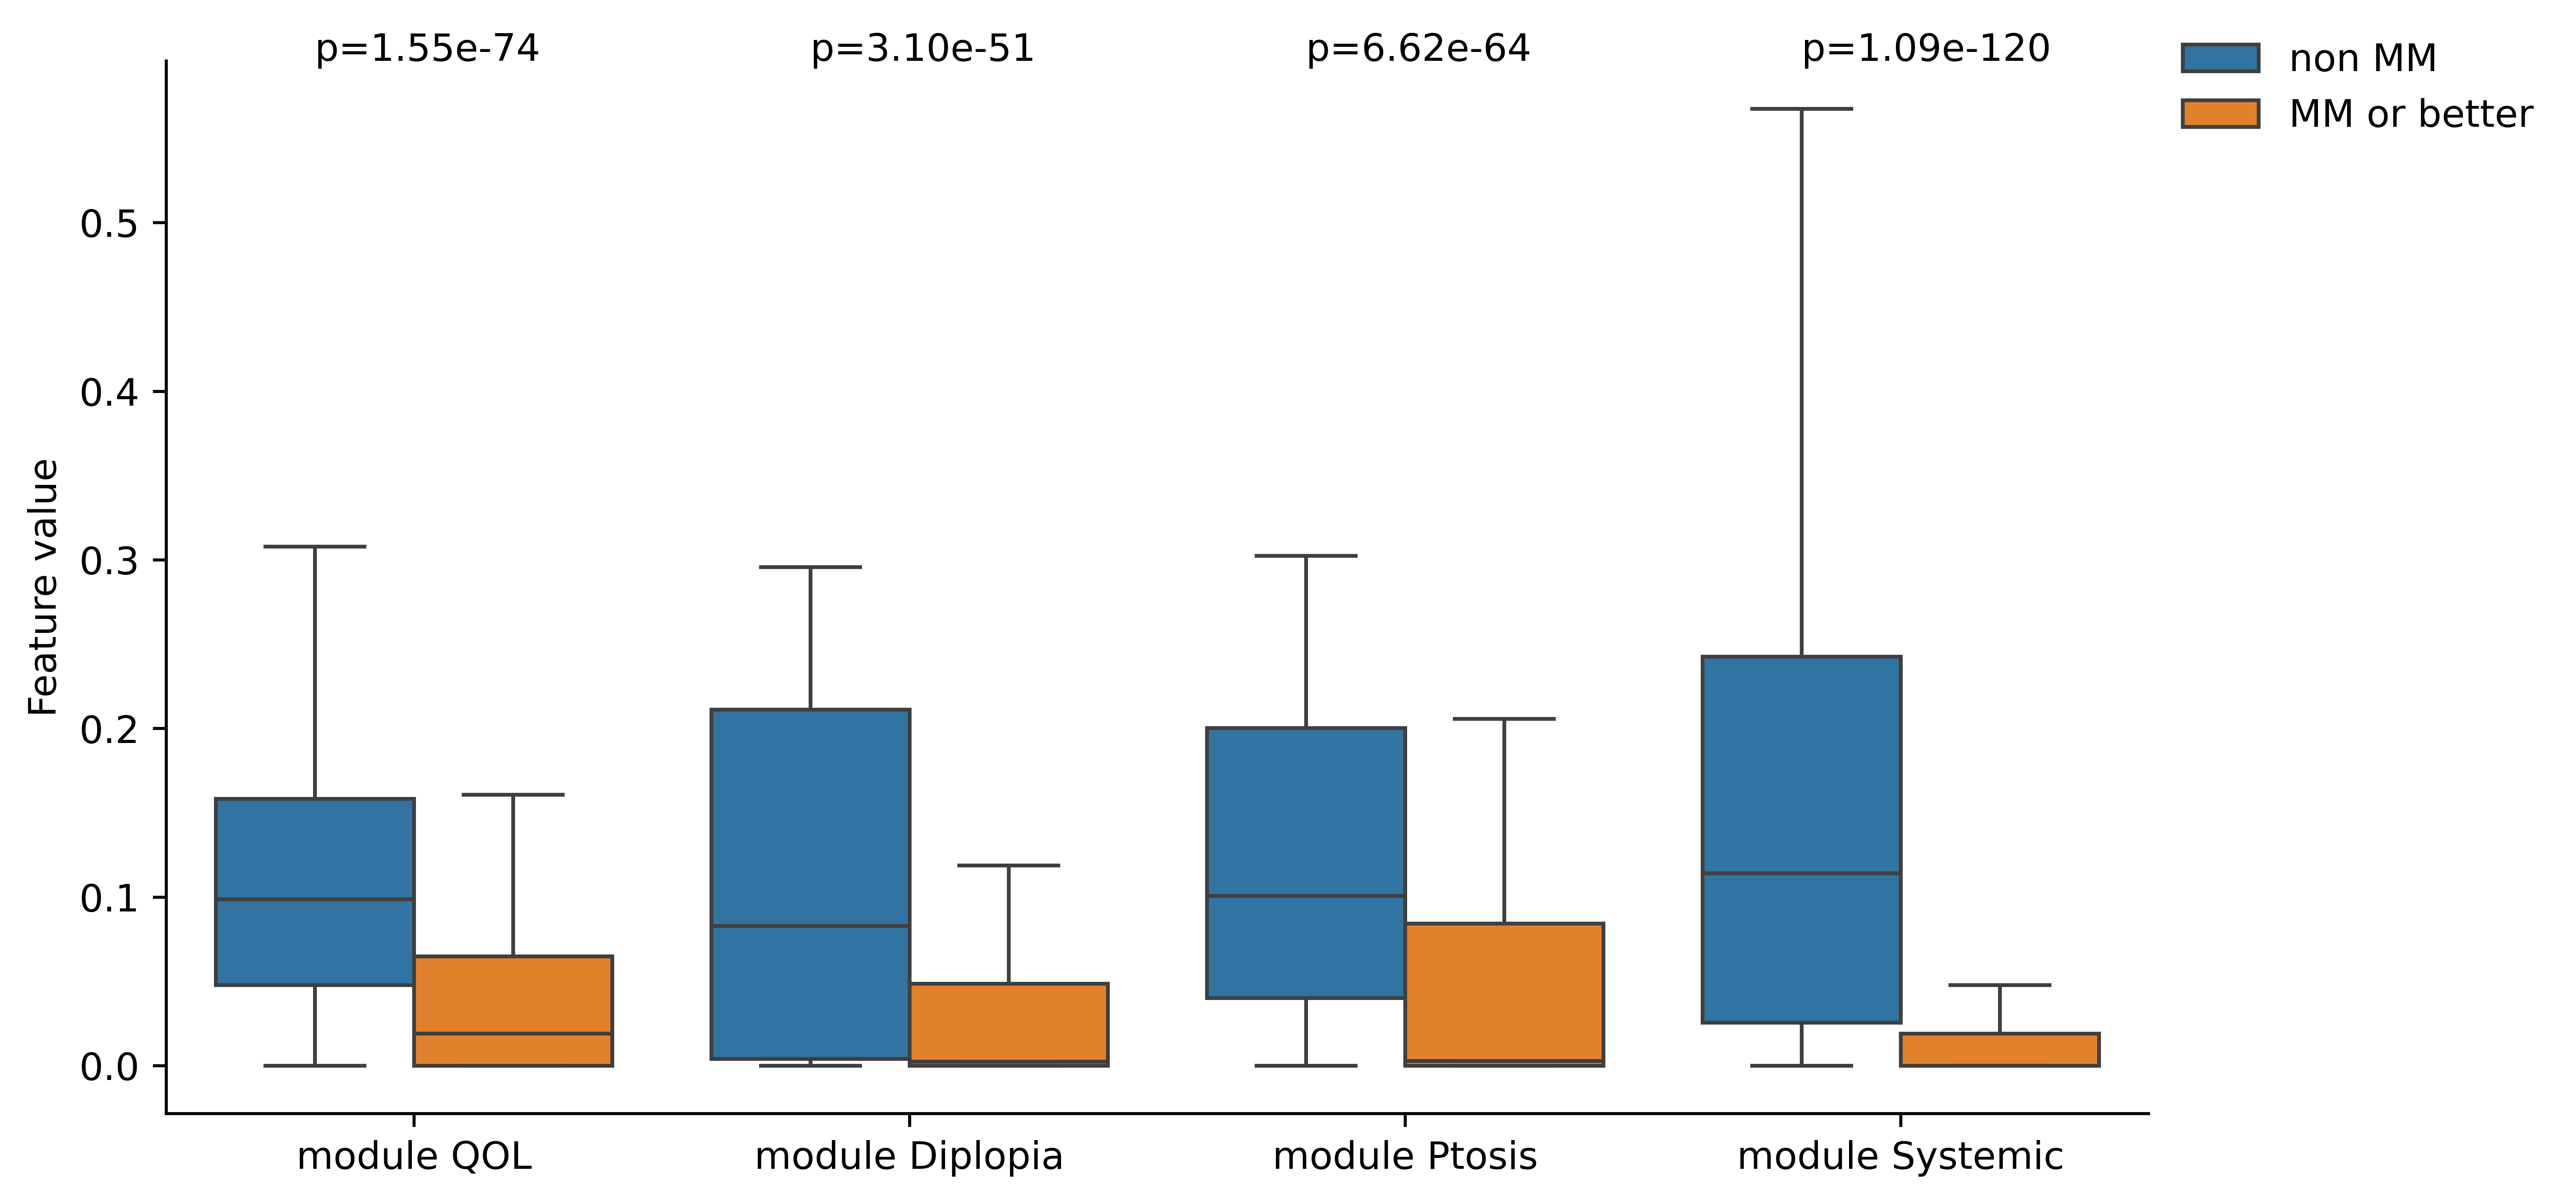

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

your_case = None

# First, we need to reformat our data to use a long format, suitable for boxplot
long_data = pd.concat([MM0.drop('MMorbetter', axis=1).assign(Group='non MM'),
                       MM1.drop('MMorbetter', axis=1).assign(Group='MM or better')])

# Create a DataFrame with the median values of each feature for MM0 and MM1
MM0_median = MM0.median()
MM1_median = MM1.median()
med_df = pd.DataFrame({"MM0_median": MM0_median, "MM1_median": MM1_median}).drop(['MMorbetter'], axis=0)

fig, ax = plt.subplots(figsize=(10, 5), dpi=800)

# Perform Mann-Whitney U test and apply multiple testing correction
p_values = [mannwhitneyu(MM0[module], MM1[module])[1] for module in med_df.index]
corrected_p_values = multipletests(p_values, method="bonferroni")[1]

# Plot MM0 and MM1 using boxplot
sns.boxplot(x="variable", y="value", hue="Group", data=pd.melt(long_data, id_vars='Group'), palette=['#1f77b4', '#ff7f0e'], ax=ax, showfliers=False)

# Display corrected p values
for i, p_val in enumerate(corrected_p_values):
    ax.text(i - 0.2, ax.get_ylim()[1]*1.0, f"p={p_val:.2e}", ha="left")

# Plot case values based on prediction probability if available
if your_case is not None:
    scatter_pos = 1 if rounded_prediction_proba >= 0.6 else 0
    for i, module in enumerate(med_df.index):
        ax.scatter(i + (scatter_pos - 0.5) * 0.4, your_case[module], color="r", marker="o", s=50, label="Your case" if i == 0 else '', edgecolors='black')

ax.set(ylabel="Feature value")
ax.set_title("")
ax.set_xlabel('')
ax.set_xticklabels(med_df.index)
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1.05))
plt.subplots_adjust(right=0.85)

sns.despine()


# Save the plot as TIFF
plt.savefig('./fig/fig3.pdf', format='pdf', dpi=1500, transparent=True)
plt.savefig('./fig/fig3.tiff', format='tiff', dpi=1500, transparent=True)

# Show the plot
plt.show()

# step2. prediction with NMF matrix

In [19]:
import pickle
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc

In [20]:
with open('./out/nmf_model.pkl', 'rb') as file:
    nmf = pickle.load(file)

with open('./out/W_matrix.pkl', 'rb') as file:
    W = pickle.load(file)

with open('./out/H_matrix.pkl', 'rb') as file:
    H = pickle.load(file)

with open('./out/W_with_id_df.pkl', 'rb') as file:
    W_with_id_df = pickle.load(file)

with open('./out/W_MM.pkl', 'rb') as file:
    W_MM = pickle.load(file)

In [21]:
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

In [22]:
kf = KFold(n_splits=5, random_state=seed, shuffle=True)

for train_index, test_index in kf.split(W_MM):
    W_train, W_test = W_MM.iloc[train_index], W_MM.iloc[test_index]
    
    X_train = W_train[["module QOL", "module Diplopia", "module Ptosis", "module Systemic"]]
    y_train = W_train["MMorbetter"]

    X_test = W_test[["module QOL", "module Diplopia", "module Ptosis", "module Systemic"]]
    y_test = W_test["MMorbetter"]

    X_train_list.append(X_train)
    y_train_list.append(y_train)
    X_test_list.append(X_test)
    y_test_list.append(y_test)

In [23]:
def save_to_pickle(data, filename):
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

In [24]:
save_to_pickle(X_train_list, './out/X_train_list.pkl')
save_to_pickle(y_train_list, './out/y_train_list.pkl')
save_to_pickle(X_test_list, './out/X_test_list.pkl')
save_to_pickle(y_test_list, './out/y_test_list.pkl')

In [25]:
param_grids = {
    'svm': {
        "C": [0.1, 1, 10, 100],
        "kernel": ["linear", "rbf"],
        "gamma": ["auto", "scale"]
    },
    'logreg': [
        {
            "penalty": ["l1", "l2"],
            "C": [0.1, 1, 10, 100],
            "fit_intercept": [True, False],
            "solver": ['liblinear', 'saga'],
        },
        {
            "penalty": ["elasticnet"],
            "C": [0.1, 1, 10, 100],
            "fit_intercept": [True, False],
            "l1_ratio": [0, 0.25, 0.5, 0.75, 1],
            "solver": ['saga'],
        },
        {
            "penalty": [None],
            "fit_intercept": [True, False],
            "solver": ['newton-cg', 'lbfgs', 'sag', 'saga'],
        }
    ],
    'rf': {
        "n_estimators": [10, 50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }
}

best_params_list = []  
best_scores_list = []  
predicted_probs_list = {
    "SVM": [],
    "Logistic Regression": [],
    "Random Forest": [],
    "Naive Bayes": []
}

models = {
    "SVM": svm.SVC(probability=True, random_state=seed),
    "Logistic Regression": LogisticRegression(random_state=seed),
    "Random Forest": RandomForestClassifier(random_state=seed),
    "Naive Bayes": GaussianNB()
}

for X_train, y_train, X_test, y_test in zip(X_train_list, y_train_list, X_test_list, y_test_list):
    
    tuned_models = {}
    best_scores = {}
    
    for model_name, model in models.items():
        if model_name != "Naive Bayes":
            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grids.get(model_name.lower(), {}),
                cv=5,
                scoring="accuracy",
                n_jobs=-1
            )
            grid_search.fit(X_train, y_train)
            tuned_models[model_name] = grid_search.best_estimator_
            best_scores[model_name] = grid_search.best_score_
        else:
            model.fit(X_train, y_train)
            tuned_models[model_name] = model
            best_scores[model_name] = model.score(X_train, y_train) 
    
    best_params = {name: model.get_params() for name, model in tuned_models.items() if name != "Naive Bayes"}
    
    best_params_list.append(best_params)
    best_scores_list.append(best_scores)
    
    for model_name, model in tuned_models.items():
        predicted_probs = model.predict_proba(X_test)[:, 1]
        predicted_probs_list[model_name].append(predicted_probs)


In [26]:
def plot_roc_curve(y_test_list, model_probs_list, model_name):
    plt.figure(figsize=(10, 10))
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = 0.0
    
    for i, (y_test, probas) in enumerate(zip(y_test_list, model_probs_list)):
        fpr, tpr, thresholds = roc_curve(y_test, probas)
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
        plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {i+1} (AUC = {auc(fpr, tpr):.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='black', alpha=0.5)
    mean_tpr /= len(y_test_list)
    plt.plot(mean_fpr, mean_tpr, color='blue', lw=2, alpha=0.8, label=f'Mean ROC (AUC = {auc(mean_fpr, mean_tpr):.2f})')
    plt.xlabel('1-Specificity')
    plt.ylabel('Sensitivity')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc="lower right")
    plt.show()

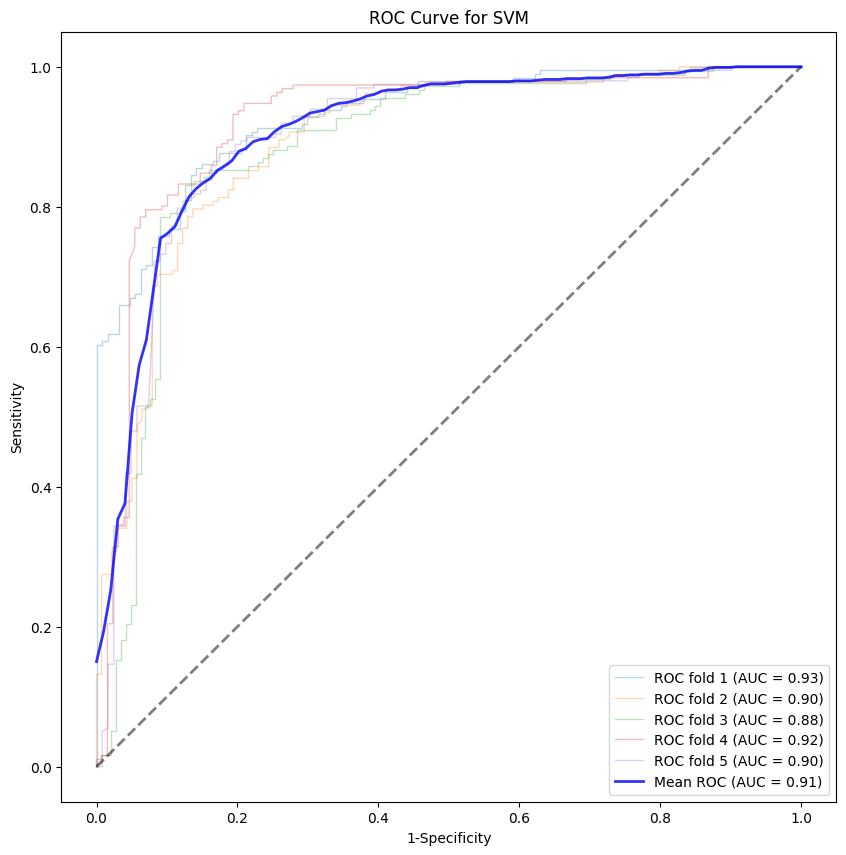

In [27]:
plot_roc_curve(y_test_list, predicted_probs_list["SVM"], "SVM")

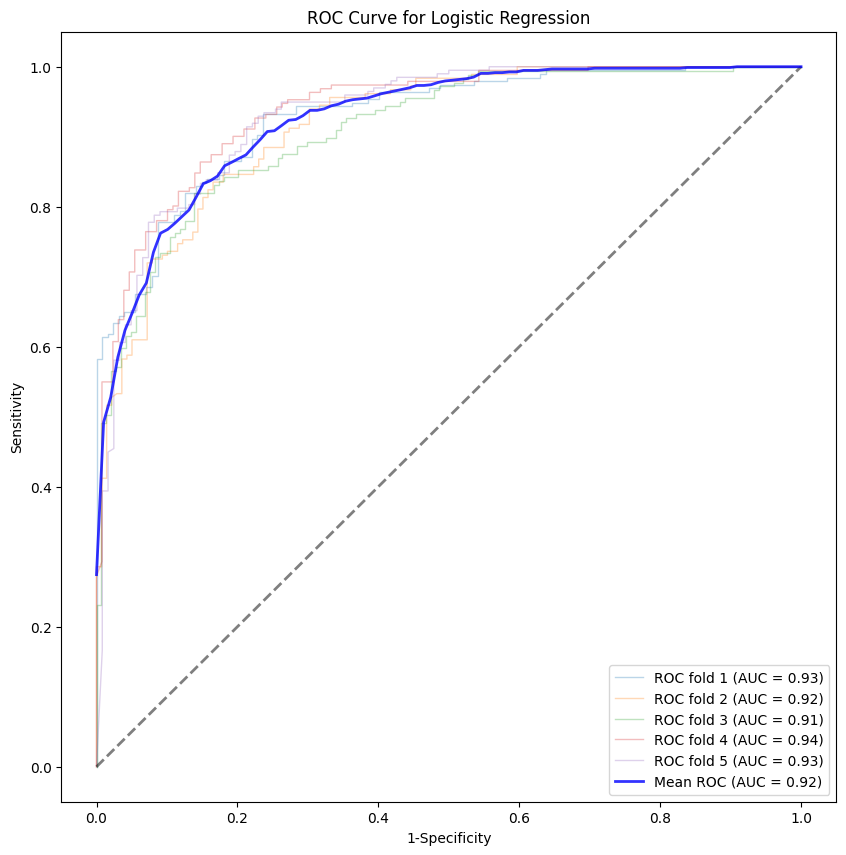

In [28]:
plot_roc_curve(y_test_list, predicted_probs_list["Logistic Regression"], "Logistic Regression")

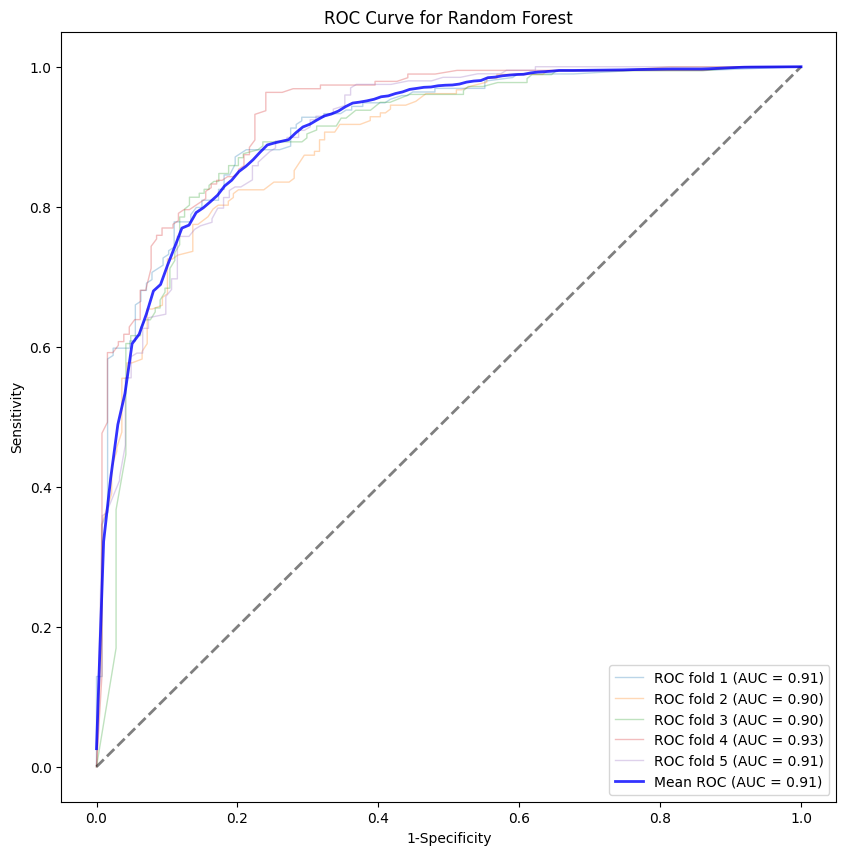

In [29]:
plot_roc_curve(y_test_list,  predicted_probs_list["Random Forest"], "Random Forest")

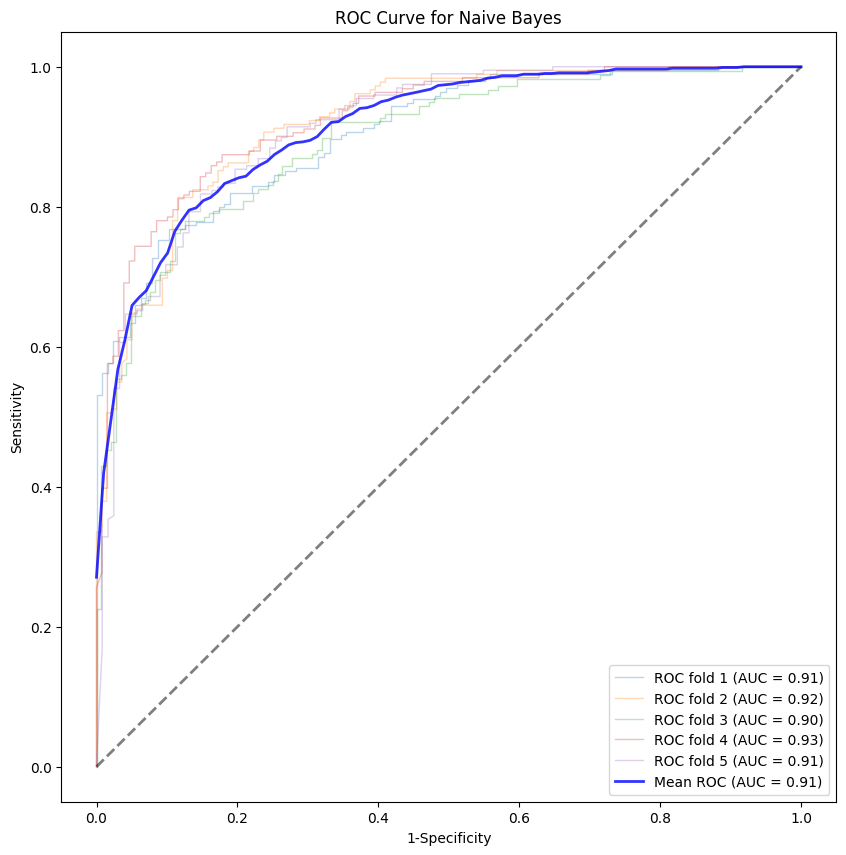

In [30]:
plot_roc_curve(y_test_list,  predicted_probs_list["Naive Bayes"], "Naive Bayes")

SHAP Plot for SVM


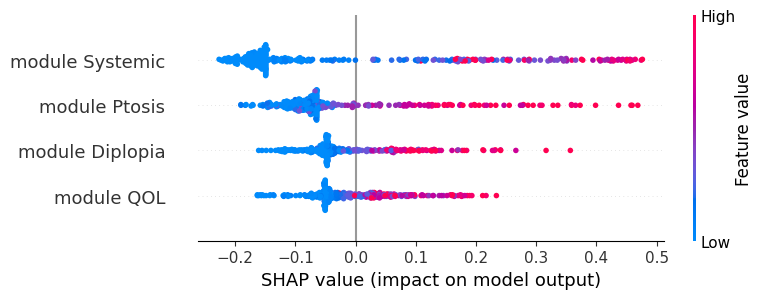

SHAP Plot for Logistic Regression


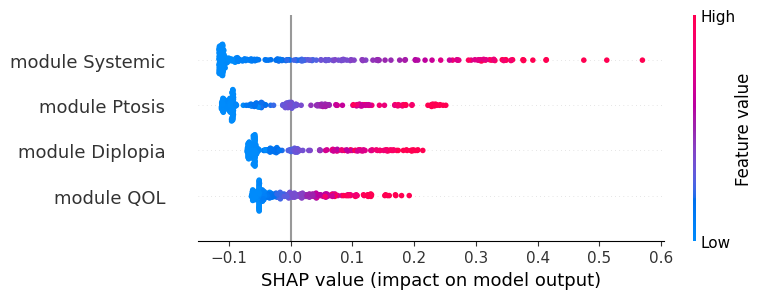

SHAP Plot for Random Forest


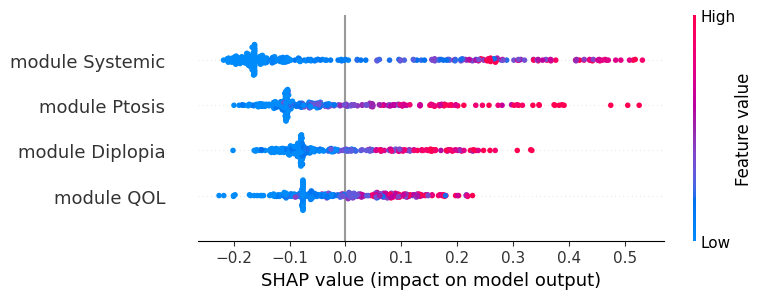

SHAP Plot for Naive Bayes


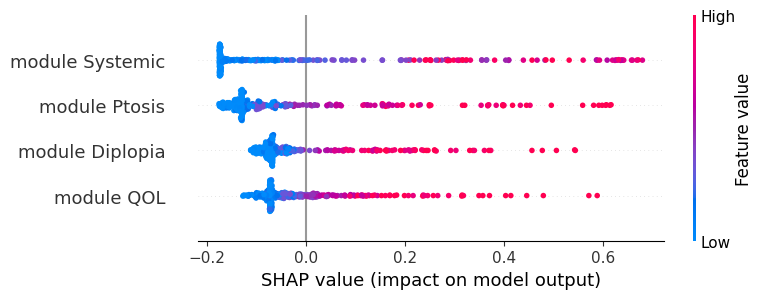

In [31]:
import numpy as np
import shap
import matplotlib.pyplot as plt

shap_values_accumulated = {
    "SVM": [],
    "Logistic Regression": [],
    "Random Forest": [],
    "Naive Bayes": []
}

def calculate_and_accumulate_shap(model, X_train, X_test, model_name):
    explainer = shap.Explainer(model.predict_proba, X_train)
    shap_values = explainer(X_test)
    shap_values_accumulated[model_name].append(shap_values.values[:, :, 0])
    return shap_values.data

def plot_average_shap(shap_values_list, feature_data, model_name, feature_names=None):
    shap_values_mean = np.mean(np.array(shap_values_list), axis=0)
    print(f"SHAP Plot for {model_name}")
    shap.summary_plot(shap_values_mean, feature_data, feature_names=feature_names)
    plt.show()

feature_data = None
for model_name, model in tuned_models.items():
    if hasattr(model, "predict_proba"):
        feature_data = calculate_and_accumulate_shap(model, X_train, X_test, model_name)

for model_name, shap_values_list in shap_values_accumulated.items():
    if shap_values_list:
        plot_average_shap(
            shap_values_list,
            feature_data,
            model_name,
            feature_names=X_train.columns if hasattr(X_train, 'columns') else None
        )

SHAP Bar Plot for SVM


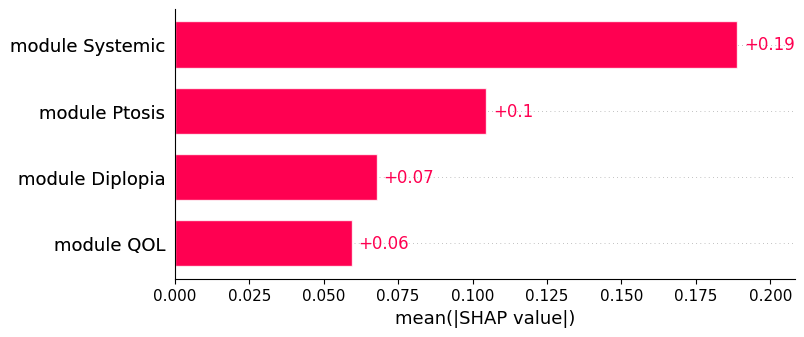

SHAP Bar Plot for Logistic Regression


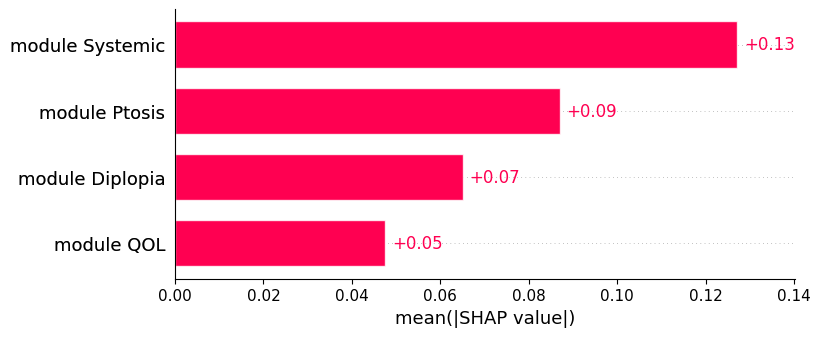

SHAP Bar Plot for Random Forest


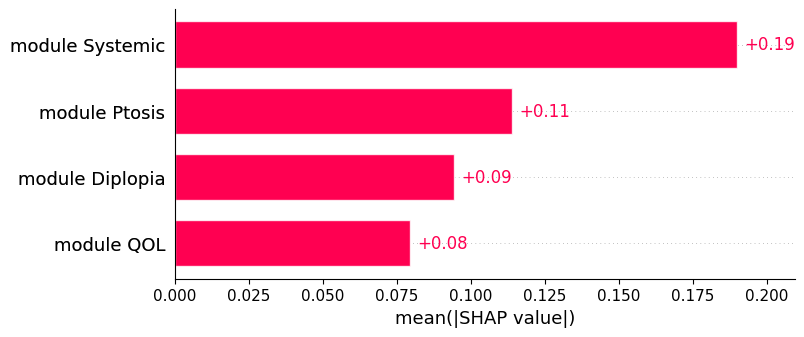

SHAP Bar Plot for Naive Bayes


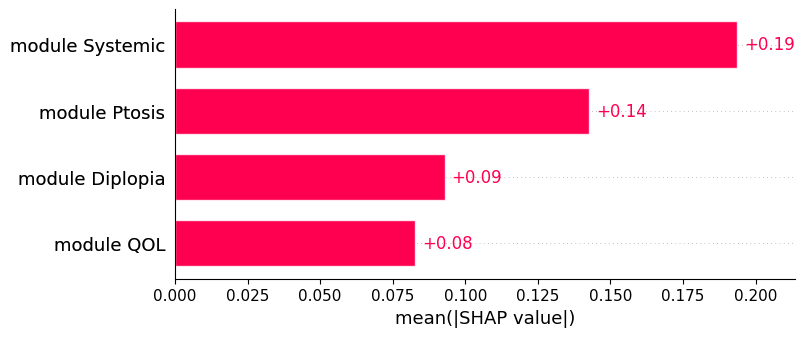

In [32]:
import numpy as np
import shap
import matplotlib.pyplot as plt

for model_name, shap_values_list in shap_values_accumulated.items():
    if shap_values_list:
        mean_shap_values = np.mean([np.abs(shap_vals) for shap_vals in shap_values_list], axis=0)
        
        shap_values = shap.Explanation(
            values=mean_shap_values,
            data=X_test,
            feature_names=X_train.columns if hasattr(X_train, 'columns') else None
        )
        
        print(f"SHAP Bar Plot for {model_name}")
        shap.plots.bar(shap_values)
        plt.show()


In [33]:
def save_mean_roc_data(y_test_list, model_probs_list, model_name, roc_data_dict):
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = 0.0
    
    for y_test, probas in zip(y_test_list, model_probs_list):
        fpr, tpr, thresholds = roc_curve(y_test, probas)
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
    
    mean_tpr /= len(y_test_list)
    mean_auc = auc(mean_fpr, mean_tpr)
    
    roc_data_dict[model_name] = {
        "mean_fpr": mean_fpr,
        "mean_tpr": mean_tpr,
        "mean_auc": mean_auc
    }

In [34]:
roc_data = {}

save_mean_roc_data(y_test_list, predicted_probs_list["SVM"], "SVM", roc_data)
save_mean_roc_data(y_test_list, predicted_probs_list["Logistic Regression"], "Logistic Regression", roc_data)
save_mean_roc_data(y_test_list, predicted_probs_list["Random Forest"], "Random Forest", roc_data)
save_mean_roc_data(y_test_list, predicted_probs_list["Naive Bayes"], "Naive Bayes", roc_data)

In [35]:
for model_name, data in roc_data.items():
    df = pd.DataFrame({
        "FPR": data["mean_fpr"],
        "TPR": data["mean_tpr"]
    })
    csv_path = f"./out/mean_roc_data_{model_name}.csv"
    df.to_csv(csv_path, index=False)

In [36]:
def get_optimal_cutoff(filename):
    data = pd.read_csv(filename)
    data['Youdens_Index'] = data['TPR'] - data['FPR']
    optimal_cutoff = data.loc[data['Youdens_Index'].idxmax()]
    
    return optimal_cutoff

In [37]:
model_files = {
    "SVM": './out/mean_roc_data_SVM.csv',
    "Logistic Regression": './out/mean_roc_data_Logistic Regression.csv',
    "Random Forest": './out/mean_roc_data_Random Forest.csv',
    "GaussianNB": './out/mean_roc_data_Naive Bayes.csv'
}

In [38]:
optimal_cutoffs = {}

for model, filename in model_files.items():
    optimal_cutoff = get_optimal_cutoff(filename)
    print(f"Optimal Cutoff for {model}:")
    print(optimal_cutoff)
    print("---------------")
    
    optimal_cutoffs[model] = optimal_cutoff['Youdens_Index']

with open('./out/optimal_cutoffs.pkl', 'wb') as f:
    pickle.dump(optimal_cutoffs, f)

Optimal Cutoff for SVM:
FPR              0.141414
TPR              0.825773
Youdens_Index    0.684359
Name: 14, dtype: float64
---------------
Optimal Cutoff for Logistic Regression:
FPR              0.151515
TPR              0.832931
Youdens_Index    0.681416
Name: 15, dtype: float64
---------------
Optimal Cutoff for Random Forest:
FPR              0.141414
TPR              0.791621
Youdens_Index    0.650207
Name: 14, dtype: float64
---------------
Optimal Cutoff for GaussianNB:
FPR              0.131313
TPR              0.795145
Youdens_Index    0.663832
Name: 13, dtype: float64
---------------


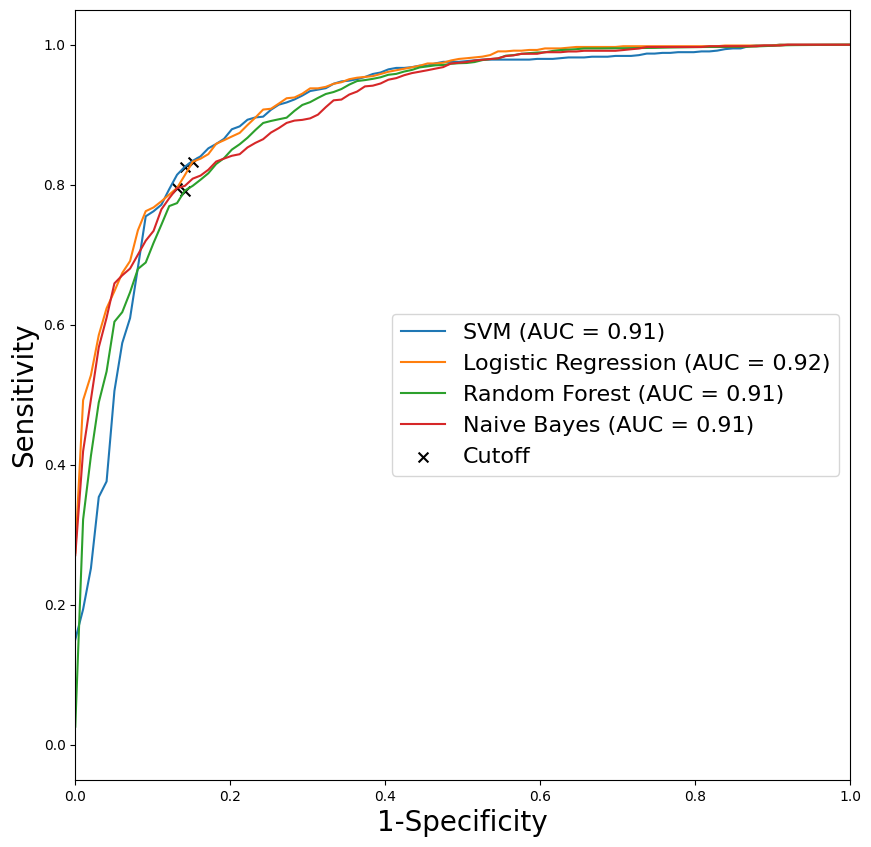

In [39]:
plt.figure(figsize=(10, 10))

handles, labels = [], []

for model_name, data in roc_data.items():
    mean_fpr = data["mean_fpr"]
    mean_tpr = data["mean_tpr"]
    mean_auc = data["mean_auc"]
    
    line, = plt.plot(mean_fpr, mean_tpr, label=f'{model_name} (AUC = {mean_auc:.2f})')
    handles.append(line)
    labels.append(f'{model_name} (AUC = {mean_auc:.2f})')
    
    optimal_cutoff = get_optimal_cutoff(f'./out/mean_roc_data_{model_name}.csv')
    cutoff_fpr = optimal_cutoff['FPR']
    cutoff_tpr = optimal_cutoff['TPR']
    
    point = plt.scatter(cutoff_fpr, cutoff_tpr, color='black', s=50, marker='x')

handles.append(point)
labels.append("Cutoff")

plt.xlim([0, 1]) 
plt.plot([1, 0], [0, 1], linestyle='--', lw=1, color='black', alpha=0)
plt.title('')
plt.legend(handles, labels, loc="center right")
plt.xlabel('1-Specificity', fontsize=20)  
plt.ylabel('Sensitivity', fontsize=20) 
plt.title('', fontsize=18)
plt.legend(handles, labels, loc="center right", fontsize=16)  

plt.savefig('./fig/fig4.pdf', format='pdf', dpi=1500, transparent=False)
plt.savefig('./fig/fig4.tiff', format='tiff', dpi=1500, transparent=False)

plt.show()

In [40]:
def save_model(model, filename):
    with open(filename, 'wb') as file:
        pickle.dump(model, file)

In [41]:
save_model(tuned_models["SVM"], './out/svm_model.pkl')
save_model(tuned_models['Logistic Regression'], './out/logreg_model.pkl')
save_model(tuned_models['Random Forest'], './out/rf_model.pkl')
save_model(tuned_models['Naive Bayes'], './out/nb_model.pkl')

In [42]:
predicted_probs_files = {
    'svm': predicted_probs_list["SVM"],
    'logreg': predicted_probs_list["Logistic Regression"],
    'rf': predicted_probs_list['Random Forest'],
    'nb': predicted_probs_list['Naive Bayes']
}

for model_name, probs_list in predicted_probs_files.items():
    save_to_pickle(probs_list, f'./out/predicted_probs_{model_name}_list.pkl')

# step3. Ensemble predictions

In [43]:
from sklearn.metrics import accuracy_score

In [44]:
def load_from_pickle(filename):
    with open(filename, 'rb') as f:
        return pickle.load(f)

In [45]:
def load_model(filename):
    with open(filename, 'rb') as file:
        return pickle.load(file)

In [46]:
X_train_list = load_from_pickle('./out/X_train_list.pkl')
y_train_list = load_from_pickle('./out/y_train_list.pkl')
X_test_list = load_from_pickle('./out/X_test_list.pkl')
y_test_list = load_from_pickle('./out/y_test_list.pkl')

In [47]:
svm_model_loaded = load_model('./out/svm_model.pkl')
logreg_model_loaded = load_model('./out/logreg_model.pkl')
rf_model_loaded = load_model('./out/rf_model.pkl')
nb_model_loaded = load_model('./out/nb_model.pkl')

In [48]:
with open('./out/predicted_probs_svm_list.pkl', 'rb') as file:
    predicted_probs_svm_list = pickle.load(file)
with open('./out/predicted_probs_logreg_list.pkl', 'rb') as file:
    predicted_probs_logreg_list = pickle.load(file)
with open('./out/predicted_probs_rf_list.pkl', 'rb') as file:
    predicted_probs_rf_list = pickle.load(file)
with open('./out/predicted_probs_nb_list.pkl', 'rb') as file:
    predicted_probs_nb_list = pickle.load(file)

In [49]:
predicted_probs_df = pd.DataFrame({
    'SVM': np.concatenate(predicted_probs_svm_list),
    'LogReg': np.concatenate(predicted_probs_logreg_list),
    'RandomForest': np.concatenate(predicted_probs_rf_list),
    'NaiveBayes': np.concatenate(predicted_probs_nb_list)
})

correlation_matrix = predicted_probs_df.corr()

print(correlation_matrix)

                   SVM    LogReg  RandomForest  NaiveBayes
SVM           1.000000  0.923852      0.927237    0.905603
LogReg        0.923852  1.000000      0.911965    0.927292
RandomForest  0.927237  0.911965      1.000000    0.863281
NaiveBayes    0.905603  0.927292      0.863281    1.000000


In [50]:
ensemble_predictions = []

for X_train, y_train, X_test, y_test in zip(X_train_list, y_train_list, X_test_list, y_test_list):
    predictions_svm = svm_model_loaded.predict(X_test)
    predictions_logreg = logreg_model_loaded.predict(X_test)
    predictions_rf = rf_model_loaded.predict(X_test)
    predictions_nb = nb_model_loaded.predict(X_test)
    predictions_df = pd.DataFrame({
        'SVM': predictions_svm,
        'LogReg': predictions_logreg,
        'RandomForest': predictions_rf,
        'NaiveBayes': predictions_nb
    })
    majority_vote = (predictions_df.sum(axis=1) >= 3).astype(int)
    ensemble_predictions.extend(majority_vote.tolist())

In [51]:
ensemble_predictions = np.array(ensemble_predictions)

y_test_all = np.concatenate(y_test_list)

ensemble_accuracy = accuracy_score(y_test_all, ensemble_predictions)

In [52]:
print(f'Ensemble accuracy: {ensemble_accuracy}')

Ensemble accuracy: 0.8839675608234561


In [53]:
auc_scores = []
ensemble_probs = []

for X_train, y_train, X_test, y_test in zip(X_train_list, y_train_list, X_test_list, y_test_list):
    
    probs_svm = svm_model_loaded.predict_proba(X_test)[:, 1]
    probs_logreg = logreg_model_loaded.predict_proba(X_test)[:, 1]
    probs_rf = rf_model_loaded.predict_proba(X_test)[:, 1]
    probs_nb = nb_model_loaded.predict_proba(X_test)[:, 1]
    
    probs_ensemble = (probs_svm + probs_logreg + probs_rf + probs_nb) / 4
    ensemble_probs.extend(probs_ensemble)
    
    fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, probs_ensemble)
    roc_auc_ensemble = auc(fpr_ensemble, tpr_ensemble)
    auc_scores.append(roc_auc_ensemble)

In [54]:
fpr_ensemble, tpr_ensemble, thresholds_ensemble = roc_curve(y_test_all, ensemble_probs)
roc_auc_ensemble = auc(fpr_ensemble, tpr_ensemble)

assert len(ensemble_probs) == len(y_test_all), "Lengths of predicted probabilities and actual labels do not match."

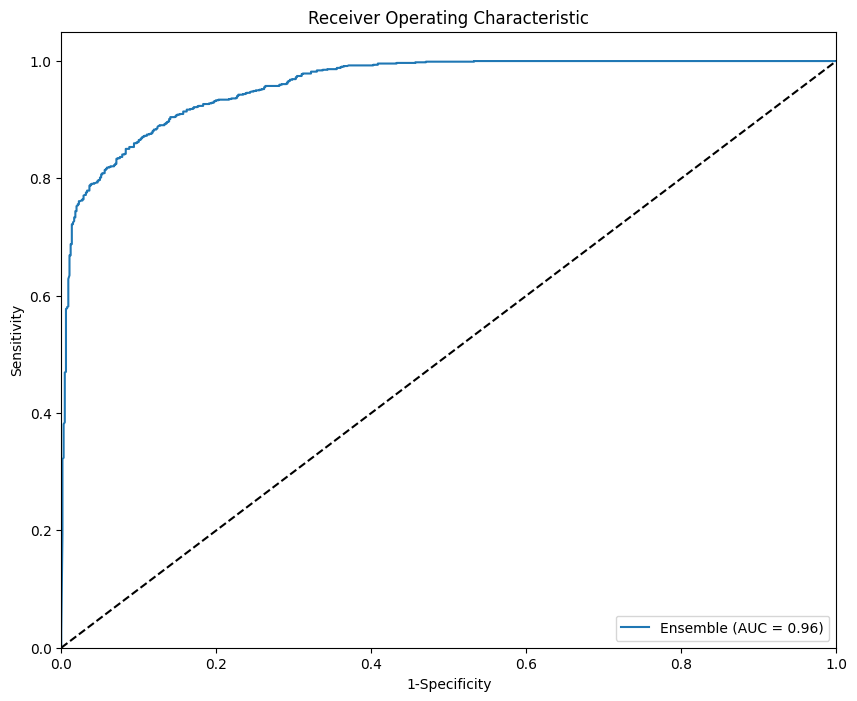

In [55]:
plt.figure(figsize=(10, 8))
plt.plot(fpr_ensemble, tpr_ensemble, label='Ensemble (AUC = %0.2f)' % roc_auc_ensemble)
plt.plot([0, 1], [0, 1], 'k--', label='')  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity')
plt.ylabel('Sensitivity')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# step4. validation

In [56]:
# Step 1: Load the original data and H matrix
import numpy as np
import pandas as pd
import pickle
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from sklearn.exceptions import NotFittedError
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# Load the original dataset and H matrix
original_df_path = "./data/df_4th.csv"
validation_df_path = "./data/df_3rd.csv"
df_ori = pd.read_csv(original_df_path, index_col=0)
df_val_ori = pd.read_csv(validation_df_path, index_col=0, encoding='cp1252')

with open('./out/H_matrix.pkl', 'rb') as file:
    H = pickle.load(file)

# Define constants
max_iter = 100

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Prepare scaled data
df_names = [
    "MGC_ptosis", "MGC_diplopia", "MGC_eyelid_closure", "MGC_speech", "MGC_chewing", 
    "MGC_swallowing", "MGC_respiration", "MGC_neck", "MGC_upper_limb", "MGC_lower_limb",
    "MGADL_speech", "MGADL_chewing", "MGADL_swallowing", "MGADL_respiration", 
    "MGADL_toothbrushing", "MGADL_getting_up", "MGADL_diplopia", "MGADL_ptosis",
    "MGQOL1_dissatisfaction", "MGQOL2_seeing", "MGQOL3_eating", 
    "MGQOL4_social_activity_restriction", "MGQOL5_hobby_entertainment", "MGQOL6_family_role", 
    "MGQOL7_behavior_modification", "MGQOL8_work_impact", "MGQOL9_speaking", 
    "MGQOL10_driving", "MGQOL11_feeling_down", "MGQOL12_walking", "MGQOL13_quick_action", 
    "MGQOL14_mental_crushing", "MGQOL15_dressing"
]

df_val = df_val_ori[df_names]
df_val_scaled = pd.DataFrame(scaler.fit_transform(df_val), columns=df_val.columns)

df = df_ori[df_names]
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Load pre-trained models
svm_model_loaded = pickle.load(open('./out/svm_model.pkl', 'rb'))
logreg_model_loaded = pickle.load(open('./out/logreg_model.pkl', 'rb'))
rf_model_loaded = pickle.load(open('./out/rf_model.pkl', 'rb'))
nb_model_loaded = pickle.load(open('./out/nb_model.pkl', 'rb'))

# Load optimal cutoff values
with open('./out/optimal_cutoffs.pkl', 'rb') as f:
    optimal_cutoffs = pickle.load(f)

# Step 2: Loop through each validation case, append to original data, and predict W
true_labels = []
predictions = {"svm": [], "logreg": [], "rf": [], "nb": []}
probabilities = {"svm": [], "logreg": [], "rf": [], "nb": []}

W_validation_list = []

for i in range(df_val_scaled.shape[0]):
    # Step 2-1: Extract the validation sample and concatenate it to the original data
    validation_sample = df_val_scaled.iloc[i:i+1]
    concatenated_df_scaled = pd.concat([df_scaled, validation_sample], axis=0)

    # Step 2-2: Create W from the concatenated data using the existing H matrix
    W_concatenated = np.random.rand(concatenated_df_scaled.shape[0], H.shape[0])

    for _ in range(max_iter):
        numer = concatenated_df_scaled.values @ H.T
        denom = W_concatenated @ (H @ H.T)
        denom = np.where(denom == 0, 1, denom)  # Prevent division by zero
        W_concatenated *= numer / denom

    # Step 2-3: Extract the W representation for the new validation sample
    W_validation_sample = W_concatenated[-1:, :]
    W_validation_list.append(W_validation_sample.flatten())

    X_validation = pd.DataFrame(W_validation_sample, columns=["module QOL", "module Diplopia", "module Ptosis", "module Systemic"])

    # Step 2-4: Make predictions using the pre-trained models
    prob_svm = svm_model_loaded.predict_proba(X_validation)[:, 1]
    prob_logreg = logreg_model_loaded.predict_proba(X_validation)[:, 1]
    prob_rf = rf_model_loaded.predict_proba(X_validation)[:, 1]
    prob_nb = nb_model_loaded.predict_proba(X_validation)[:, 1]

    probabilities["svm"].append(prob_svm[0])
    probabilities["logreg"].append(prob_logreg[0])
    probabilities["rf"].append(prob_rf[0])
    probabilities["nb"].append(prob_nb[0])

    # Step 2-5: Apply optimal cutoffs and store predictions
    pred_svm = (prob_svm >= optimal_cutoffs['SVM']).astype(int)
    pred_logreg = (prob_logreg >= optimal_cutoffs['Logistic Regression']).astype(int)
    pred_rf = (prob_rf >= optimal_cutoffs['Random Forest']).astype(int)
    pred_nb = (prob_nb >= optimal_cutoffs['GaussianNB']).astype(int)

    predictions["svm"].append(pred_svm[0])
    predictions["logreg"].append(pred_logreg[0])
    predictions["rf"].append(pred_rf[0])
    predictions["nb"].append(pred_nb[0])

    # Step 2-6: Store the true label
    y_val = df_val_ori["MMorbetter"].iloc[i]
    true_labels.append(y_val)

# Step 3: Evaluate model accuracy and create confusion matrices
for model_name in predictions.keys():
    y_pred = predictions[model_name]
    cm = confusion_matrix(true_labels, y_pred)
    accuracy = accuracy_score(true_labels, y_pred)
   
# Step 4: Majority vote ensemble
predictions_df = pd.DataFrame(predictions)
majority_vote = (predictions_df.sum(axis=1) >= 3).astype(int)

# Evaluate majority vote ensemble accuracy and create confusion matrix
cm_majority = confusion_matrix(true_labels, majority_vote)
accuracy_majority = accuracy_score(true_labels, majority_vote)
print(f"Confusion Matrix for majority vote ensemble model:\n{cm_majority}")
print(f"Accuracy for majority vote ensemble model: {accuracy_majority:.2f}\n")

# Step 5: Calculate and plot ROC for majority vote ensemble using average probabilities
average_probabilities = (np.array(probabilities["svm"]) + np.array(probabilities["logreg"]) + np.array(probabilities["rf"]) + np.array(probabilities["nb"])) / 4

fpr, tpr, _ = roc_curve(true_labels, average_probabilities)
roc_auc = auc(fpr, tpr)

Confusion Matrix for majority vote ensemble model:
[[143  18]
 [ 42 211]]
Accuracy for majority vote ensemble model: 0.86



In [57]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, matthews_corrcoef, precision_score, recall_score

true_labels = np.array(true_labels)  # 真のラベル
majority_vote = np.array(majority_vote)  # アンサンブルによる予測ラベル
average_probabilities = np.array(average_probabilities)  # 平均確率予測

cm = confusion_matrix(true_labels, majority_vote)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(true_labels, majority_vote)
auc_score = roc_auc_score(true_labels, average_probabilities)
sensitivity = recall_score(true_labels, majority_vote)  # 感度（再現率）
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0  # 特異度
precision = precision_score(true_labels, majority_vote)  # 精度
f1 = f1_score(true_labels, majority_vote)
mcc = matthews_corrcoef(true_labels, majority_vote)

metrics_df = pd.DataFrame({
    "Metric": ["AUC", "Sensitivity (Recall)", "Specificity", "Precision", "Accuracy", "F1 Score", "MCC"],
    "Value": [auc_score, sensitivity, specificity, precision, accuracy, f1, mcc]
})

metrics_df

,Metric,Value
0,AUC,0.941006
1,Sensitivity (Recall),0.833992
2,Specificity,0.888199
3,Precision,0.921397
4,Accuracy,0.855072
5,F1 Score,0.875519
6,MCC,0.708144


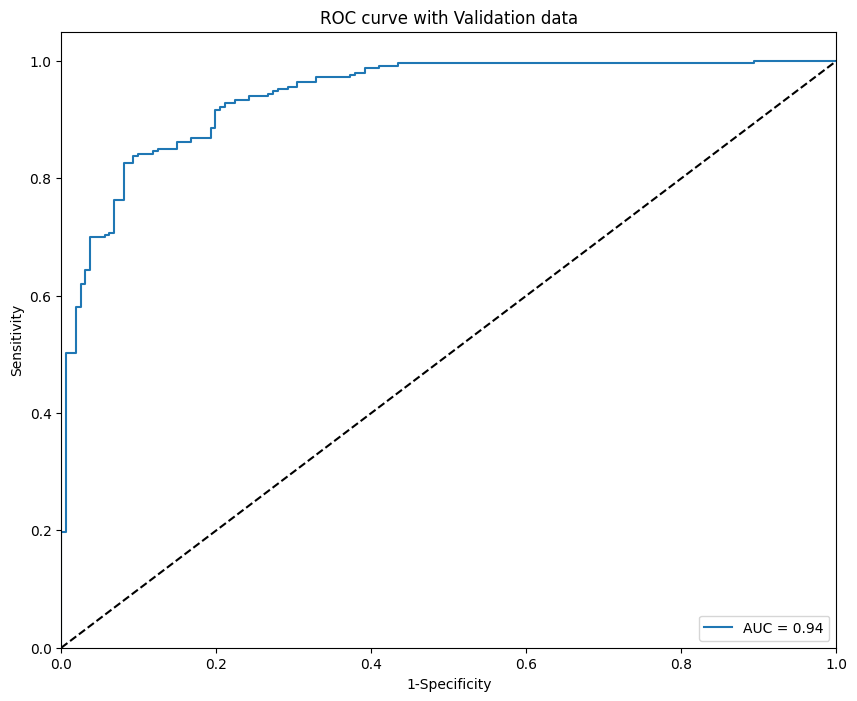

In [58]:
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='')  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity')
plt.ylabel('Sensitivity')
plt.title("ROC curve with Validation data")
plt.legend(loc="lower right")

plt.savefig('./fig/fig5.pdf', format='pdf', dpi=1500, transparent=False)
plt.savefig('./fig/fig5.tiff', format='tiff', dpi=1500, transparent=False)

plt.show()

In [59]:
# Step 6: Collect results into a final DataFrame
results = pd.DataFrame()

# 各検証サンプルの特徴量（元のスコア）を追加
results['ID'] = df_val_ori.index
results[df_names] = df_val.reset_index(drop=True)

# W 行列の特徴量を DataFrame に変換して追加
modules = ["module_QOL", "module_Diplopia", "module_Ptosis", "module_Systemic"]
W_validation_df = pd.DataFrame(W_validation_list, columns=modules)
results[modules] = W_validation_df

# 各モデルの予測結果を追加
results['SVM_Prediction'] = predictions["svm"]
results['Logistic_Regression_Prediction'] = predictions["logreg"]
results['Random_Forest_Prediction'] = predictions["rf"]
results['Naive_Bayes_Prediction'] = predictions["nb"]

# 各モデルの確率予測を追加
results['SVM_Probability'] = probabilities["svm"]
results['Logistic_Regression_Probability'] = probabilities["logreg"]
results['Random_Forest_Probability'] = probabilities["rf"]
results['Naive_Bayes_Probability'] = probabilities["nb"]

# アンサンブル（多数決）の結果も追加
results['Majority_Vote_Prediction'] = majority_vote
results['True_Label'] = true_labels
results['correct'] = (results['Majority_Vote_Prediction'] == results['True_Label']).astype(int)

# df_val_ori から追加の情報を加える
results['Sex'] = df_val_ori['Sex'].reset_index(drop=True)
results['Age'] = df_val_ori['Age'].reset_index(drop=True)
results['Onset_age'] = df_val_ori['Onset_age'].reset_index(drop=True)
results['PSL_dose'] = df_val_ori['PSL_dose'].reset_index(drop=True)
results['MG_subtypes'] = df_val_ori['MG_subtypes'].reset_index(drop=True).astype('category') 

# MG_subtypes をカテゴリカルデータに変換
subtype_mapping = {
    1: 'OMG',
    2: 'EOMG',
    3: 'LOMG',
    4: 'TAMG',
    5: 'MuSK',
    6: 'SNMG'
}
results['MG_subtypes'] = df_val_ori['MG_subtypes'].map(subtype_mapping).reset_index(drop=True)

In [60]:
# 結果の保存
output_csv_path = './out/validation_results.csv'
results.to_csv(output_csv_path, index=False)
print(f"Results saved to {output_csv_path}")

Results saved to ./out/validation_results.csv


Analyzing incorrect cases where True_Label = 0


/var/folders/9v/25ky5ynx3fv57ncrm5lt41980000gn/T/ipykernel_33613/2218612782.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', len(incorrect_cases))


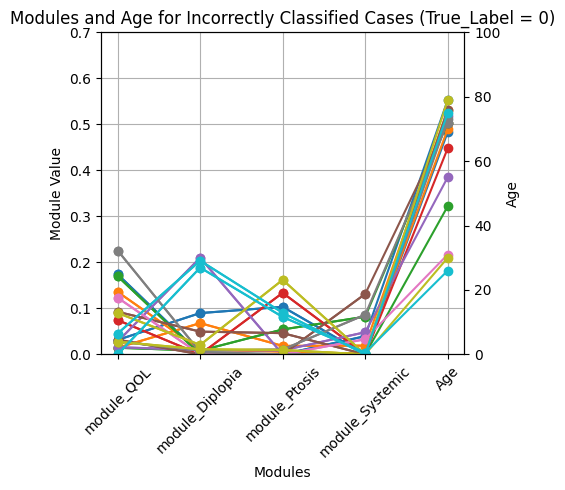

Analyzing incorrect cases where True_Label = 1


/var/folders/9v/25ky5ynx3fv57ncrm5lt41980000gn/T/ipykernel_33613/2218612782.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', len(incorrect_cases))


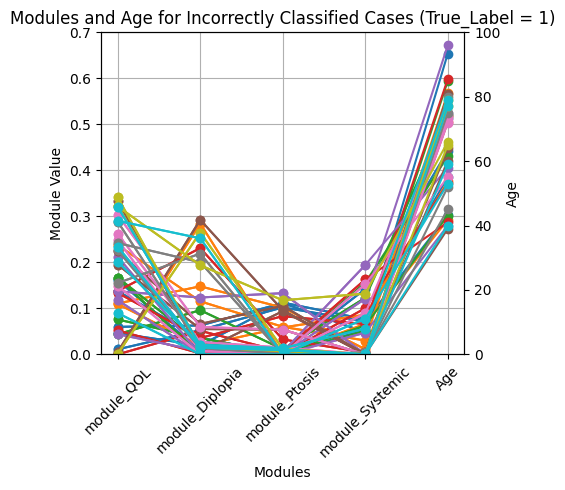

In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm

# 分析対象の modules 特徴量
items = ["module_QOL", "module_Diplopia", "module_Ptosis", "module_Systemic"]

def plot_incorrect_cases(data, true_label_value):
    """
    True_Label の値に基づいて、誤分類された症例をプロットし、modulesとAgeを別々のy軸で線で繋げる関数。
    modules と Age の線の色を揃える。
    """
    # True_Label でフィルタリングし、correct = 0 のデータのみ抽出
    incorrect_cases = data[(data['True_Label'] == true_label_value) & (data['correct'] == 0)]

    if incorrect_cases.empty:
        print(f"No incorrect cases for True_Label = {true_label_value}")
        return

    plt.figure(figsize=(5, 5))
    
    # modules のプロット用の軸（左側）
    ax1 = plt.gca()
    ax2 = ax1.twinx()  # Age 用の軸（右側）

    # カラーマップの設定（症例ごとに異なる色を割り当て）
    colors = cm.get_cmap('tab10', len(incorrect_cases))

    for i, (index, row) in enumerate(incorrect_cases.iterrows()):
        # 各症例の modules の特徴量を取得
        items_values = row[items].values
        original_index = row.name  # 元のインデックス
        age_value = row['Age']  # Age の値

        # 症例ごとに色を設定
        color = colors(i)

        # 左側のy軸に modules をプロット（症例ごとに異なる色）
        ax1.plot(items, items_values, marker='o', color=color, label=f'Index {original_index}')
        
        # modules の最後の点と Age の点を同じ色で結ぶ
        ax1.plot(
            items + ['Age'], 
            list(items_values) + [age_value * 0.007],  # Age の値を modules のスケールに合わせて調整
            linestyle='-', marker='o', markersize=6, color=color
        )

    # グラフの装飾
    ax1.set_title(f"Modules and Age for Incorrectly Classified Cases (True_Label = {true_label_value})")
    ax1.set_xlabel("Modules")
    ax1.set_ylabel("Module Value")
    ax1.set_ylim(0, 0.7)
    ax1.grid(True)
    #ax1.legend(title='Original Index', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.set_xticks(range(len(items) + 1))
    ax1.set_xticklabels(items + ['Age'], rotation=45)

    # 右側のy軸の設定
    ax2.set_ylabel("Age")
    ax2.set_ylim(0, 100)  # Age の範囲に合わせて調整

    plt.tight_layout()
    plt.show()

# True_Label = 0 のケースをプロット
print("Analyzing incorrect cases where True_Label = 0")
plot_incorrect_cases(results, true_label_value=0)

# True_Label = 1 のケースをプロット
print("Analyzing incorrect cases where True_Label = 1")
plot_incorrect_cases(results, true_label_value=1)


Analyzing incorrect cases where True_Label = 0


/var/folders/9v/25ky5ynx3fv57ncrm5lt41980000gn/T/ipykernel_33613/1491827991.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', len(incorrect_cases))


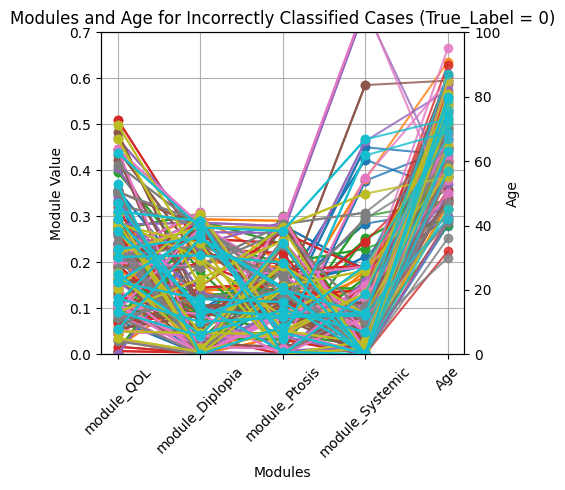

Analyzing incorrect cases where True_Label = 1


/var/folders/9v/25ky5ynx3fv57ncrm5lt41980000gn/T/ipykernel_33613/1491827991.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', len(incorrect_cases))


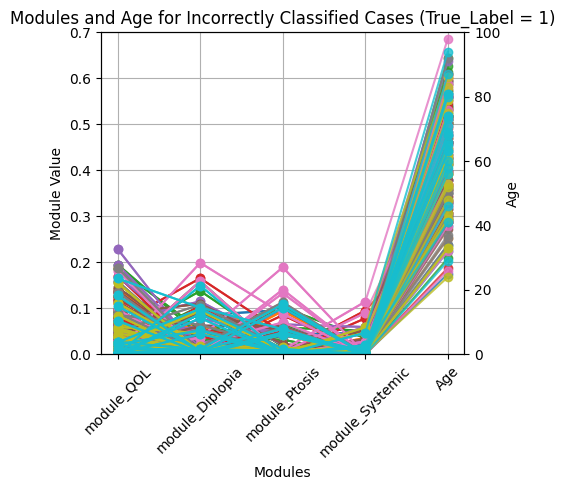

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm

# 分析対象の modules 特徴量
items = ["module_QOL", "module_Diplopia", "module_Ptosis", "module_Systemic"]

def plot_incorrect_cases(data, true_label_value):
    """
    True_Label の値に基づいて、誤分類された症例をプロットし、modulesとAgeを別々のy軸で線で繋げる関数。
    modules と Age の線の色を揃える。
    """
    # True_Label でフィルタリングし、correct = 1 のデータのみ抽出
    incorrect_cases = data[(data['True_Label'] == true_label_value) & (data['correct'] == 1)]

    if incorrect_cases.empty:
        print(f"No incorrect cases for True_Label = {true_label_value}")
        return

    plt.figure(figsize=(5, 5))
    
    # modules のプロット用の軸（左側）
    ax1 = plt.gca()
    ax2 = ax1.twinx()  # Age 用の軸（右側）

    # カラーマップの設定（症例ごとに異なる色を割り当て）
    colors = cm.get_cmap('tab10', len(incorrect_cases))

    for i, (index, row) in enumerate(incorrect_cases.iterrows()):
        # 各症例の modules の特徴量を取得
        items_values = row[items].values
        original_index = row.name  # 元のインデックス
        age_value = row['Age']  # Age の値

        # 症例ごとに色を設定
        color = colors(i)

        # 左側のy軸に modules をプロット（症例ごとに異なる色）
        ax1.plot(items, items_values, marker='o', color=color, label=f'Index {original_index}')
        
        # modules の最後の点と Age の点を同じ色で結ぶ
        ax1.plot(
            items + ['Age'], 
            list(items_values) + [age_value * 0.007],  # Age の値を modules のスケールに合わせて調整
            linestyle='-', marker='o', markersize=6, color=color, alpha=0.8
        )

    # グラフの装飾
    ax1.set_title(f"Modules and Age for Incorrectly Classified Cases (True_Label = {true_label_value})")
    ax1.set_xlabel("Modules")
    ax1.set_ylabel("Module Value")
    ax1.set_ylim(0, 0.7)
    ax1.grid(True)
    #ax1.legend(title='Original Index', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.set_xticks(range(len(items) + 1))
    ax1.set_xticklabels(items + ['Age'], rotation=45)

    # 右側のy軸の設定
    ax2.set_ylabel("Age")
    ax2.set_ylim(0, 100)  # Age の範囲に合わせて調整

    plt.tight_layout()
    plt.show()

# True_Label = 0 のケースをプロット
print("Analyzing incorrect cases where True_Label = 0")
plot_incorrect_cases(results, true_label_value=0)

# True_Label = 1 のケースをプロット
print("Analyzing incorrect cases where True_Label = 1")
plot_incorrect_cases(results, true_label_value=1)


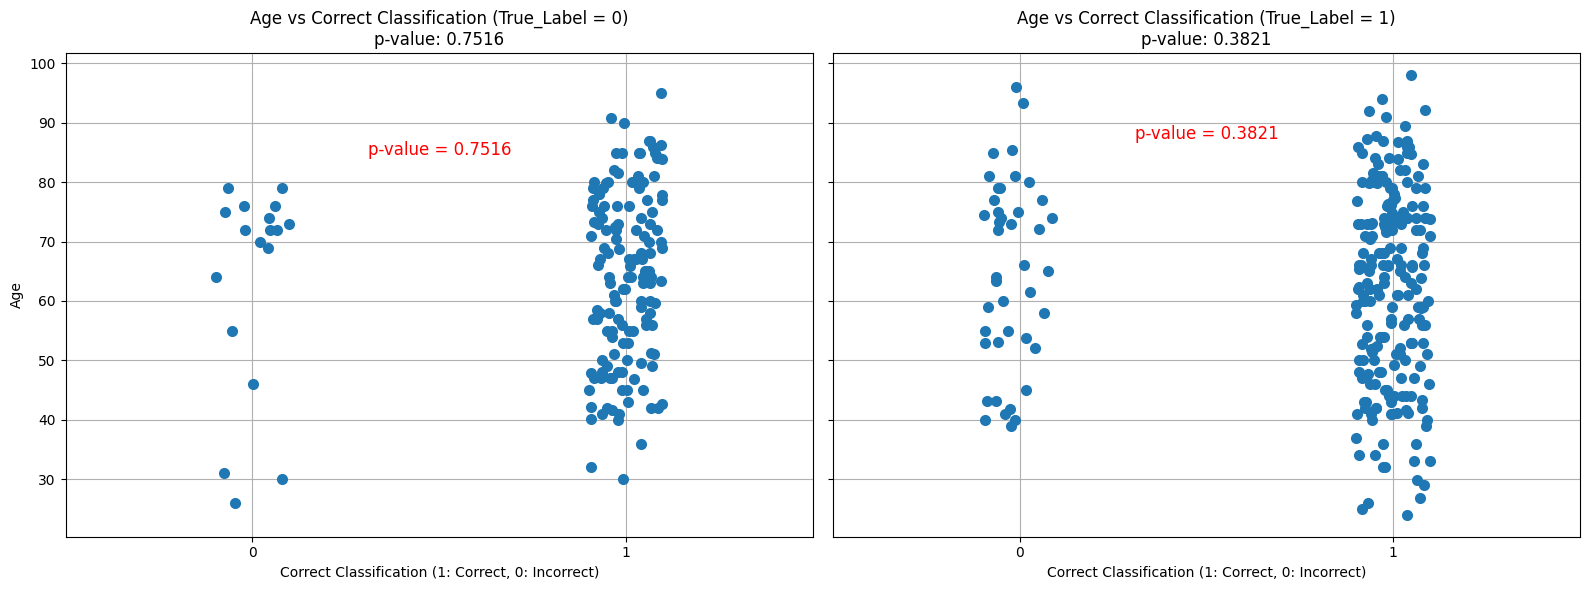

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

def plot_age_vs_correct_with_pvalue(data, true_label_value, ax):
    """
    True_Label の値に基づいて、correct と Age の関係をドットプロットで描画し、p値を計算して表示。
    """
    # データのフィルタリング
    subset = data[data['True_Label'] == true_label_value]
    
    # correct = 0 と correct = 1 の年齢データを取得
    age_correct = subset[subset['correct'] == 1]['Age']
    age_incorrect = subset[subset['correct'] == 0]['Age']
    
    # 正規性検定
    _, p_value_correct = stats.shapiro(age_correct)
    _, p_value_incorrect = stats.shapiro(age_incorrect)

    # 正規性検定の結果に基づいて、t検定またはU検定を実行
    if p_value_correct > 0.05 and p_value_incorrect > 0.05:
        # 両方が正規分布の場合、t検定を使用
        _, p_value = stats.ttest_ind(age_correct, age_incorrect, equal_var=False)
    else:
        # 正規分布でない場合、U検定を使用
        _, p_value = stats.mannwhitneyu(age_correct, age_incorrect)
    
    # ドットプロットの作成
    sns.stripplot(x='correct', y='Age', data=subset, ax=ax, jitter=True, size=8)
    ax.set_title(f'Age vs Correct Classification (True_Label = {true_label_value})\np-value: {p_value:.4f}')
    ax.set_xlabel('Correct Classification (1: Correct, 0: Incorrect)')
    ax.set_ylabel('Age')
    ax.grid(True)
    
    # p値の注釈を追加
    ax.text(0.5, max(subset['Age']) * 0.9, f'p-value = {p_value:.4f}', 
            ha='center', va='center', fontsize=12, color='red')

# グラフの描画
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# True_Label = 0 の場合
plot_age_vs_correct_with_pvalue(results, true_label_value=0, ax=axes[0])

# True_Label = 1 の場合
plot_age_vs_correct_with_pvalue(results, true_label_value=1, ax=axes[1])

# レイアウト調整
plt.tight_layout()
plt.show()
